In [2]:
import pandas as pd
import numpy as np

dge = pd.read_csv("../../data/sc_GPT_knockout_dge.csv", index_col=0)
mean_abs = dge.abs().mean(axis=1).sort_values()
print(mean_abs.head(20))   # самые тихие пертурбации
print(f"\nNear-zero (mean|DGE| < 0.01): {(mean_abs < 0.01).sum()}")

FTX           0.017389
MACROD2       0.017398
JMJD1C        0.017398
CTNNA2        0.017406
RIMS2         0.017410
FGF12         0.017414
CADM2         0.017418
CELF2         0.017423
AP006222.2    0.017444
RABGAP1L      0.017448
PCLO          0.017464
IL1RAPL1      0.017476
XKR4          0.017476
RYR2          0.017478
CHRM3         0.017498
RPL37A        0.017519
RPS24         0.017533
NBEA          0.017581
SMYD3         0.017583
EEF1A1        0.017595
dtype: float64

Near-zero (mean|DGE| < 0.01): 0


In [3]:
dge_filtered = dge[dge.abs().mean(axis=1) >= 0.05]  # поиграй с порогом
print(f"Kept: {len(dge_filtered)} / {len(dge)}")

Kept: 690 / 5060


In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(dge.values)
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)
dge_pca = pd.DataFrame(X_pca, index=dge.index)
# дальше считай similarity на X_pca

In [5]:
df = pd.read_csv("../../data/MonarchKG/monarch-kg_edges.tsv", sep="\t", usecols=["subject", "predicate", "object"])

In [8]:
mask = (
    df["subject"].str.startswith(("MONDO:", "HGNC:", "HP:")) &
    df["object"].str.startswith(("MONDO:", "HGNC:", "HP:"))
)
df_filtered = df[mask]
print(f"Before: {len(df):,}  After: {len(df_filtered):,}")


Before: 15,371,045  After: 1,826,639


In [9]:
df_filtered

,predicate,subject,object
0,biolink:interacts_with,HGNC:6535,HGNC:976
1,biolink:interacts_with,HGNC:15714,HGNC:9870
2,biolink:interacts_with,HGNC:28817,HGNC:10983
3,biolink:interacts_with,HGNC:7421,HGNC:16701
4,biolink:interacts_with,HGNC:7699,HGNC:31369
...,...,...,...
15370975,biolink:subclass_of,MONDO:1011822,MONDO:1011305
15370987,biolink:subclass_of,HP:0012184,HP:0031888
15371000,biolink:subclass_of,MONDO:0024685,MONDO:0004643
15371031,biolink:subclass_of,HP:0032061,HP:0001880


In [10]:
df_filtered.to_csv("train.txt", sep="\t", index=False, header=False)

1-MNR: 0.2676  (n=6380)


FileNotFoundError: [Errno 2] No such file or directory: 'out/rankings/RareDisease_hist.png'

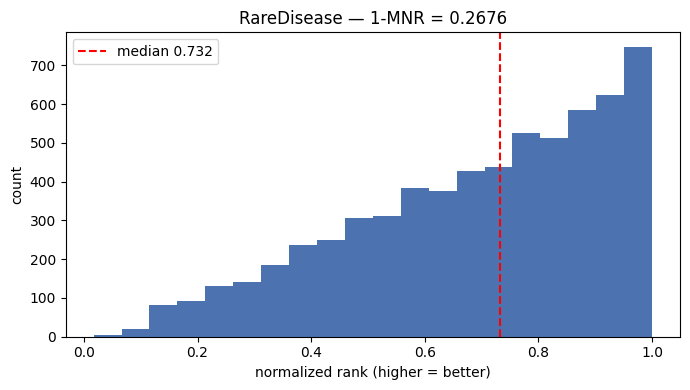

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../out/rankings/baseline_seed42_RareDisease_ranking_data.tsv", sep="\t")

mnr = 1 - df["rank"].median()
print(f"1-MNR: {mnr:.4f}  (n={len(df)})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["rank"], bins=20, color="#4c72b0", edgecolor="none")
ax.axvline(df["rank"].median(), color="red", lw=1.5, ls="--", label=f"median {df['rank'].median():.3f}")
ax.set_xlabel("normalized rank (higher = better)")
ax.set_ylabel("count")
ax.set_title(f"RareDisease — 1-MNR = {mnr:.4f}")
ax.legend()
plt.tight_layout()